In [1]:
# Se importa desde GitHub un funciones.py
!wget -O funciones.py \
https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/funciones.py

--2026-07-30 14:48:10--  https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/funciones.py
Resolving github.com (github.com)... 4.228.31.150
Connecting to github.com (github.com)|4.228.31.150|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/Proc_Img/practicos/funciones.py [following]
--2026-07-30 14:48:10--  https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/Proc_Img/practicos/funciones.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 776 [text/plain]
Saving to: ‘funciones.py’

funciones.py        100%[===================>]     776  --.-KB/s    in 0.1s    

2026-07

In [4]:
# Librerías

## Librerías generales
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os

# Import funciones.py
import funciones as fp

## Librerías para abrir imágenes desde GitHub como numpy arrays
import requests
import matplotlib.image as mpimg
from PIL import Image
from io import BytesIO

# Clase 01 - Operaciones básicas con imágenes y datos

**Funciones**

In [2]:
# Defino una función que toma una imagen como array de numpy y la ecualiza según el valor de percentil (p) definido
def scale(imagen, p):

    # Obtengo los valores de los percentiles p y 100-p
    vmin = np.percentile(imagen, p)
    vmax = np.percentile(imagen, 100-p)

    # Trunco la imagen con numpy.clip()
    img_trun = np.clip(imagen, vmin, vmax)  # Limitar los valores a este rango
    
    # Normalizar a 0-255
    img_ecual = (img_trun - vmin) / (vmax - vmin) * 255 # Si sacamos este *255 queda escalada de 0 a 1

    # Convertir la imagen ecualizada a entero de 8 bits (ya que la normalizamos y escalamos de 0 a 255)
    img_ecual = np.uint8(img_ecual)

    return img_ecual

### Ejercicio 1.3.1-Respuesta

In [4]:
# Recupero la imagen desde github
trin_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/recorte_trinidad_int.tif'

# Leo la imagen con `mpimg.imread()`
## Descargo la imagen con response
response = requests.get(trin_path)
response.raise_for_status()  # evanta un error si no puede descargar la imagen

## Leo la imagen con bytesIO
imagen_trin = mpimg.imread(BytesIO(response.content), format="tif") # BytesIO creates a file-like object from the downloaded bytes, so the image can be read without first saving it to disk

In [7]:
# Visualizo tipo de datos
print(f"Tipo de datos: {imagen_trin.dtype}")

# Visualizo dimensiones matriz
print(f"Dimensiones matriz: {imagen_trin.shape}")
# Defino percentil (P) para evaluación de valores en la imagen
P = 1

# Visualizo máx y min
print(f"Array min: {imagen_trin.min()}. Array max: {imagen_trin.max()}")

# Visualizo p:p y p: 100-P
print(f"Array p{P}: {np.nanpercentile(imagen_trin, 5):.3f}. Array p{100-P}: {np.nanpercentile(imagen_trin, 100-P):.3f}")

# Visualizo media y desvío estándar
print(f"Array media: {imagen_trin.mean()}. Array DE: {imagen_trin.std()}")

Tipo de datos: uint16
Dimensiones matriz: (1129, 1622)
Array min: 22. Array max: 65512
Array p1: 906.000. Array p99: 7003.000
Array media: 2106.7285759688257. Array DE: 1859.4542078988602


Text(0.5, 1.0, 'Histograma Original')

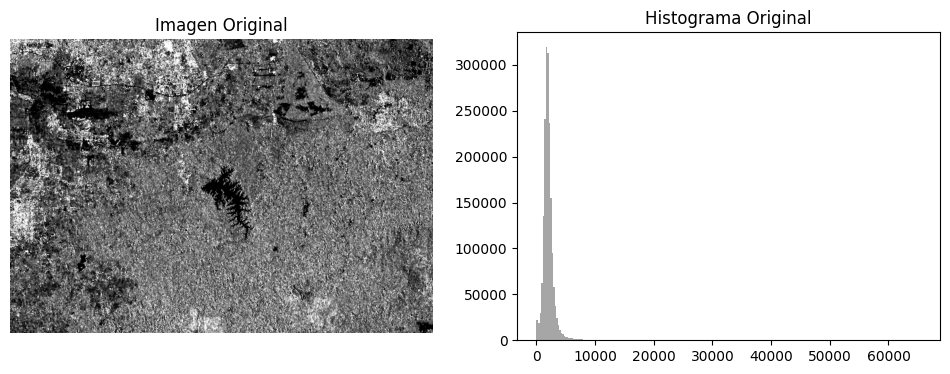

In [9]:
# Ploteo la escena de S1 y el histograma de los valores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Defino vmin y vmax para visualización según percentil (P)
P = 5
vmin = np.nanpercentile(imagen_trin, P)
vmax = np.nanpercentile(imagen_trin, 100-P)

# ---------------------- IMÁGENES ----------------------
axes[0].imshow(imagen_trin, cmap='gray',
    vmin = vmin, 
    vmax = vmax)
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].hist(imagen_trin.ravel(), bins=255, color='gray', alpha=0.7)
axes[1].set_title('Histograma Original')


### Ejercicio 1.3.3-Respuesta

In [13]:
# Recupero la imagen desde github
## Recorte de escena banda SWIR de Landsat 8 sobre el Embalse San Roque el día 22/02/2017

esr_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/l8swir_esr_20170222.tif'

## Descargo la imagen con response
response = requests.get(esr_path)
response.raise_for_status()  # evanta un error si no puede descargar la imagen

## Leo la imagen con bytesIO
imagen_esr = mpimg.imread(BytesIO(response.content), format="tif") # BytesIO creates a file-like object from the downloaded bytes, so the image can be read without first saving it to disk

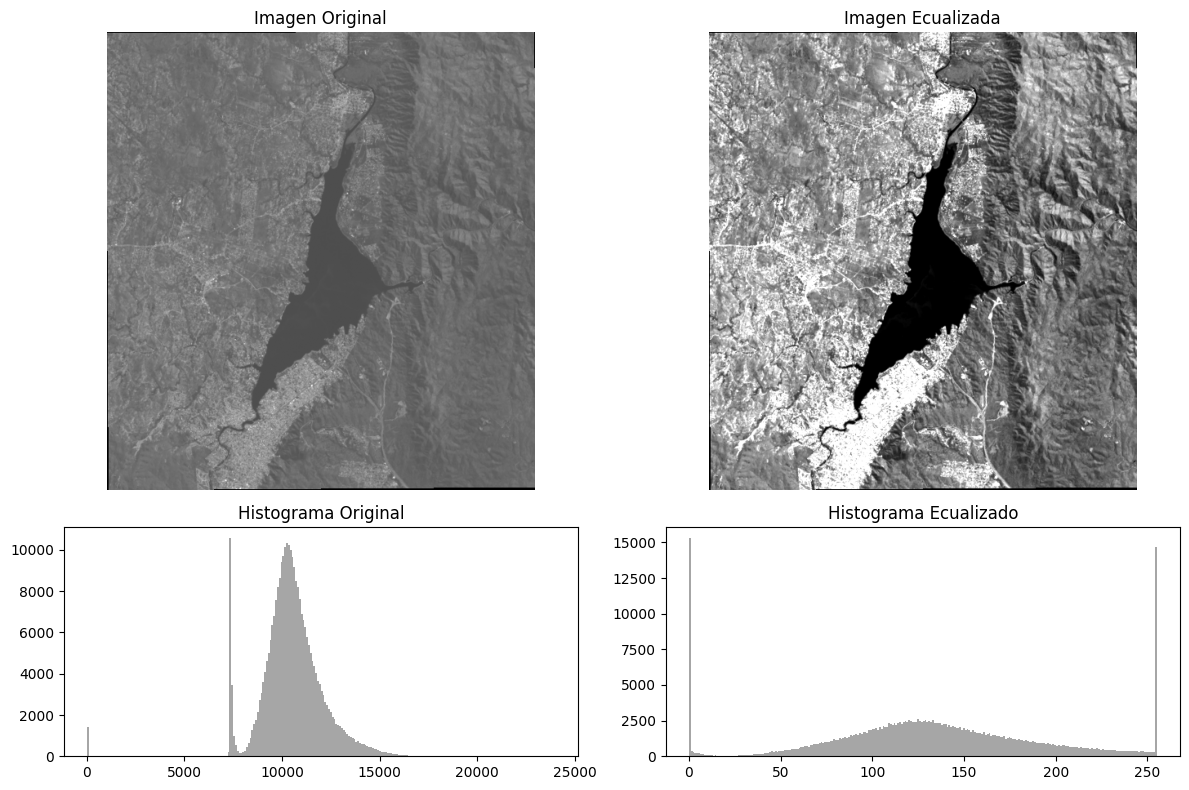

In [14]:
# Crear una figura con 2 filas: imágenes e histogramas originales y escalados
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1]})

# Defino percentil (P) para estiramiento
P = 5

# ---------------------- IMÁGENES ----------------------
axes[0, 0].imshow(imagen_esr, cmap='gray')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(scale(imagen_esr, P), cmap='gray')
axes[0, 1].set_title('Imagen Ecualizada')
axes[0, 1].axis('off')

# ---------------------- HISTOGRAMAS ----------------------
# Histograma de la imagen original
axes[1, 0].hist(imagen_esr.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 0].set_title('Histograma Original')

# Histograma de la imagen ecualizada
axes[1, 1].hist(scale(imagen_esr, P).ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 1].set_title('Histograma Ecualizado')

# Ajustar el diseño
plt.tight_layout()
plt.show()

# Clase 02 - Manipulación de imágenes satelitales con Rasterio

### Ejercicio 3.2.-Respuesta

Sobre la escena del ejercicio anterior, definí una esquina superior izquierda (`ulx,uly`) y una esquina inferior derecha (`lrx,lry`), y extraé el recángulo definido por sus coordenadas replicando el ejercicio 2.1, o utilizando la función `subset_img` del ejercicio 3.4 si ya la tenés implementada. Ploteá el recorte extraído usando `imshow`.

In [ ]:
# Leo y obtento los datos de la banda 7 una escea de Landsat 8 de Córdoba
#l8_b7_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF'
l8_b7_path = os.path.join()
l8_b7_data = rasterio.open(l8_b7_path).read()

In [3]:
# Printeo el shape
print(f'Shape: {l8_b7_data.shape}')

NameError: name 'l8_b7_data' is not defined